# Minecraft Speedrunning Ranked Player Analysis

#### Clustering of player statistics using MCSR Ranked Season 10 Data: https://mcsr-downloads.mrderp.dev/

## Data and Package Imports

In [1]:
import duckdb
import pandas as pd
from pathlib import Path

import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.mixture import GaussianMixture

import matplotlib.pyplot as plt

import math
from matplotlib.lines import Line2D


#### Initial data is stored as a parquet to help with the compute given the extreme size of the data (20+ GBs)

In [2]:
parquet_path = Path("rankedmatcheselo.parquet")

if not parquet_path.exists():
    raise FileNotFoundError(f"Could not find {parquet_path.resolve()}")

parquet_path.resolve()

WindowsPath('C:/Users/Brandon/Downloads/rankedmatcheselo.parquet')

## Querying Data into a player level granularity using DuckDB
##### This lets us extract the data without loading it all into memory (which is too intensive given our hardware)

In [3]:
query = """
WITH matches AS (
    SELECT
        id AS match_id,
        result.uuid AS winner_uuid,
        result.time AS result_time_ms,
        COALESCE(forfeited, FALSE) AS match_forfeited,
        players,
        timelines
    FROM read_parquet(?::VARCHAR)
),
player_match AS (
    SELECT
        m.match_id,
        p.unnest.uuid AS uuid,
        p.unnest.nickname AS nickname,
        p.unnest.eloRank AS elo_rank,
        m.winner_uuid,
        m.result_time_ms,
        m.match_forfeited,
        CASE
            WHEN p.unnest.uuid = m.winner_uuid THEN 'win'
            WHEN m.match_forfeited THEN 'forfeit'
            ELSE 'loss'
        END AS outcome
    FROM matches m
    CROSS JOIN UNNEST(m.players) AS p
),
event_times AS (
    SELECT
        m.match_id,
        t.unnest.uuid AS uuid,
        MIN(CASE WHEN t.unnest.type = 'projectelo.timeline.forfeit' THEN t.unnest.time END) AS forfeit_time_ms,
        MIN(CASE WHEN t.unnest.type = 'story.enter_the_nether' THEN t.unnest.time END) AS enter_nether_ms,
        MIN(CASE WHEN t.unnest.type = 'story.enter_the_end' THEN t.unnest.time END) AS enter_end_ms
    FROM matches m
    CROSS JOIN UNNEST(m.timelines) AS t
    GROUP BY 1, 2
),
player_match_enriched AS (
    SELECT
        pm.match_id,
        pm.uuid,
        pm.nickname,
        pm.elo_rank,
        pm.outcome,
        pm.result_time_ms,
        et.forfeit_time_ms,
        et.enter_nether_ms,
        et.enter_end_ms,
        CASE
            WHEN pm.outcome = 'forfeit' THEN COALESCE(et.forfeit_time_ms, pm.result_time_ms)
        END AS forfeit_duration_ms
    FROM player_match pm
    LEFT JOIN event_times et
      ON pm.match_id = et.match_id
     AND pm.uuid = et.uuid
)
SELECT
    uuid,
    arg_max(nickname, match_id) AS nickname,
    COUNT(*) AS games_played,
    arg_max(elo_rank, match_id) AS latest_rank,
    AVG(CASE WHEN outcome = 'win' THEN 1.0 ELSE 0.0 END) AS avg_win_rate,
    AVG(CASE WHEN outcome = 'forfeit' THEN 1.0 ELSE 0.0 END) AS avg_forfeit_rate,
    AVG(CASE WHEN outcome = 'win' THEN result_time_ms END) AS avg_time_win_ms,
    MIN(CASE WHEN outcome = 'win' THEN result_time_ms END) AS fastest_win_ms,
    AVG(CASE WHEN outcome = 'loss' THEN result_time_ms END) AS avg_time_loss_ms,
    AVG(forfeit_duration_ms) AS avg_time_forfeit_ms,
    AVG(enter_nether_ms) AS avg_story_enter_the_nether_ms,
    AVG(enter_end_ms) AS avg_story_enter_the_end_ms
FROM player_match_enriched
WHERE uuid IS NOT NULL
GROUP BY 1
ORDER BY uuid;
"""

In [4]:
con = duckdb.connect()

player_df = con.execute(query, [str(parquet_path)]).fetchdf()

# sanity check columns in seconds for easier interpretation of our data
ms_columns = [
    "avg_time_win_ms",
    "avg_time_loss_ms",
    "avg_time_forfeit_ms",
    "avg_story_enter_the_nether_ms",
    "avg_story_enter_the_end_ms",
]
for col in ms_columns:
    player_df[col.replace("_ms", "_sec")] = player_df[col] / 1000.0

print(f"Players extracted: {len(player_df):,}")
player_df.head()

Players extracted: 89,910


,uuid,nickname,games_played,latest_rank,avg_win_rate,avg_forfeit_rate,avg_time_win_ms,fastest_win_ms,avg_time_loss_ms,avg_time_forfeit_ms,avg_story_enter_the_nether_ms,avg_story_enter_the_end_ms,avg_time_win_sec,avg_time_loss_sec,avg_time_forfeit_sec,avg_story_enter_the_nether_sec,avg_story_enter_the_end_sec
0,0000482972604a908b8df5765f3121c0,Rawliett,1,NaN,0.0,1.0,NaN,<NA>,NaN,5.783710e+05,NaN,NaN,NaN,NaN,578.371000,NaN,NaN
1,00005d39e6e647ccb1960f061d01f9a4,AxysCold,1,NaN,1.0,0.0,300029.0,300029,NaN,NaN,NaN,NaN,300.029,NaN,NaN,NaN,NaN
2,00007f703c834361bebd79b2e8258ad3,Papka_Dota,10,10893.0,0.2,0.7,932382.0,437460,1687068.0,5.316464e+05,197516.9,NaN,932.382,1687.068,531.646429,197.5169,NaN
3,000171d71e284b9a8580cc925ad2eda3,zayzuh,1,NaN,1.0,0.0,359361.0,359361,NaN,NaN,165422.0,NaN,359.361,NaN,NaN,165.4220,NaN
4,000245c7a4e84a31bf8686c094174953,Daf_lay,1,NaN,0.0,1.0,NaN,<NA>,NaN,1.087584e+06,431398.0,NaN,NaN,NaN,1087.584000,431.3980,NaN


## Data Preprocessing

#### When extracting our data, it was noticed that there are many players with very few games played. These resulted in very extreme features (such as 100% or 0% win rates), which were not very representative of the population

In [5]:
min_games = 10

player_df_10plus = player_df[player_df["games_played"] >= min_games].copy()
player_df_10plus = player_df_10plus.dropna().copy()
player_df_10plus = player_df_10plus[player_df_10plus["fastest_win_ms"] > 0].copy()

print(f"Players with >= {min_games} games, no NaN values, and fastest_win_ms > 0: {len(player_df_10plus):,}")
player_df_10plus.head()

Players with >= 10 games, no NaN values, and fastest_win_ms > 0: 39,669


,uuid,nickname,games_played,latest_rank,avg_win_rate,avg_forfeit_rate,avg_time_win_ms,fastest_win_ms,avg_time_loss_ms,avg_time_forfeit_ms,avg_story_enter_the_nether_ms,avg_story_enter_the_end_ms,avg_time_win_sec,avg_time_loss_sec,avg_time_forfeit_sec,avg_story_enter_the_nether_sec,avg_story_enter_the_end_sec
5,00027c97590448f394c3678e14e461ae,MrKingsbury,15,33137.0,0.333333,0.600000,1.435601e+06,782471,2.538244e+06,1.492529e+06,365194.153846,2.106589e+06,1435.601000,2538.244000,1492.528778,365.194154,2106.589000
8,000332572f78457eafa71e5fbaf22db2,Kubson21_,78,8386.0,0.423077,0.423077,8.811283e+05,210209,1.042792e+06,5.830184e+05,175640.844156,9.792673e+05,881.128303,1042.791667,583.018424,175.640844,979.267273
10,00048da903b544729771ead2f0a2cffb,clickrtraineddog,136,40121.0,0.367647,0.595588,7.997705e+05,294323,1.793402e+06,9.177778e+05,323644.715447,1.696709e+06,799.770460,1793.402000,917.777802,323.644715,1696.709333
14,000738097742436d8c4d1ffbb2800548,KAITOKID6,397,6966.0,0.501259,0.110831,1.303258e+06,254334,1.330849e+06,1.156501e+06,215720.015190,1.249773e+06,1303.258050,1330.849039,1156.500705,215.720015,1249.773069
18,0008a4b72b874ccb9a363ba086b932a6,DOOMOFDEPLUSHIE,126,39277.0,0.428571,0.539683,8.994731e+05,291965,1.532241e+06,8.688375e+05,296972.558333,1.760561e+06,899.473074,1532.241000,868.837529,296.972558,1760.560667


In [6]:
output_path = Path("player_level_features.parquet")
player_df_10plus.to_parquet(output_path, index=False)

output_path.resolve()

WindowsPath('C:/Users/Brandon/Downloads/player_level_features.parquet')

## GMM Clustering Pipeline (player_df_10plus)

Pipeline:
1. Select clustering features
2. Log-transform time features
3. Standardize features
4. Apply PCA
5. Select GMM settings with BIC
6. Fit best GMM and assign cluster labels

#### Get all feature columns and identify time based columns

In [8]:
# we wont include our sanity check columns, or identifier columns
feature_cols = [
    "games_played",
    "latest_rank",
    "avg_win_rate",
    "avg_forfeit_rate",
    "avg_time_win_ms",
    "fastest_win_ms",
    "avg_time_loss_ms",
    "avg_time_forfeit_ms",
    "avg_story_enter_the_nether_ms",
    "avg_story_enter_the_end_ms",
]

time_cols = [
    "avg_time_win_ms",
    "fastest_win_ms",
    "avg_time_loss_ms",
    "avg_time_forfeit_ms",
    "avg_story_enter_the_nether_ms",
    "avg_story_enter_the_end_ms",
]

X = player_df_10plus[feature_cols].copy()
X.head()

,games_played,latest_rank,avg_win_rate,avg_forfeit_rate,avg_time_win_ms,fastest_win_ms,avg_time_loss_ms,avg_time_forfeit_ms,avg_story_enter_the_nether_ms,avg_story_enter_the_end_ms
5,15,33137.0,0.333333,0.600000,1.435601e+06,782471,2.538244e+06,1.492529e+06,365194.153846,2.106589e+06
8,78,8386.0,0.423077,0.423077,8.811283e+05,210209,1.042792e+06,5.830184e+05,175640.844156,9.792673e+05
10,136,40121.0,0.367647,0.595588,7.997705e+05,294323,1.793402e+06,9.177778e+05,323644.715447,1.696709e+06
14,397,6966.0,0.501259,0.110831,1.303258e+06,254334,1.330849e+06,1.156501e+06,215720.015190,1.249773e+06
18,126,39277.0,0.428571,0.539683,8.994731e+05,291965,1.532241e+06,8.688375e+05,296972.558333,1.760561e+06


#### The scales for our features are extremely different. Logging our time based features helps alleviate the vast differences in different entries, making it less dominant when determining our features using PCA. Standardizing our features shapes our data to be more effective with GMM.

In [9]:
X_log = X.copy()
X_log[time_cols] = np.log1p(X_log[time_cols])

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_log)

print("Scaled matrix shape:", X_scaled.shape)

Scaled matrix shape: (39669, 10)


## Dimensionality Reduction using PCA
#### GMMs are heavily affected by the curse of dimensionality, so its better to only use features with high variance from each other.
#### We are choosing to just keep enough components to explain 95% variance. This is a reasonable tradeoff between reduction and still being representative of our data

In [10]:
pca_full = PCA(random_state=42)
pca_full.fit(X_scaled)

cum_var = np.cumsum(pca_full.explained_variance_ratio_)
n_components_95 = int(np.searchsorted(cum_var, 0.95) + 1)

pca = PCA(n_components=n_components_95, random_state=42)
X_pca = pca.fit_transform(X_scaled)

kept_components = [f"PC{i}" for i in range(1, n_components_95 + 1)]
kept_variance_df = pd.DataFrame(
    {
        "component": kept_components,
        "explained_variance_ratio": pca.explained_variance_ratio_,
        "cumulative_explained_variance": np.cumsum(pca.explained_variance_ratio_),
    }
)

print(f"PCA components for 95% variance: {n_components_95}")
print(f"Total explained variance: {pca.explained_variance_ratio_.sum():.4f}")
print("Kept components:", ", ".join(kept_components))
kept_variance_df

PCA components for 95% variance: 7
Total explained variance: 0.9635
Kept components: PC1, PC2, PC3, PC4, PC5, PC6, PC7


,component,explained_variance_ratio,cumulative_explained_variance
0,PC1,0.466269,0.466269
1,PC2,0.220948,0.687217
2,PC3,0.107486,0.794703
3,PC4,0.067872,0.862575
4,PC5,0.039769,0.902344
5,PC6,0.034765,0.937109
6,PC7,0.026366,0.963474


#### Top features for each component. Helps to interpret which features are heavily weighted in our PCA output

In [11]:
loadings = pd.DataFrame(
    pca.components_.T,
    index=feature_cols,
    columns=[f"PC{i}" for i in range(1, pca.n_components_ + 1)],
)

top_n = 3
rows = []
for pc in loadings.columns:
    top_features = loadings[pc].abs().sort_values(ascending=False).head(top_n).index
    for feat in top_features:
        rows.append(
            {
                "component": pc,
                "feature": feat,
                "loading": loadings.loc[feat, pc],
                "abs_loading": abs(loadings.loc[feat, pc]),
            }
        )

pca_top_features_df = pd.DataFrame(rows).sort_values(["component", "abs_loading"], ascending=[True, False])

print(f"Top {top_n} contributing features for each kept principal component:")
pca_top_features_df

Top 3 contributing features for each kept principal component:


,component,feature,loading,abs_loading
0,PC1,avg_story_enter_the_end_ms,0.440841,0.440841
1,PC1,avg_story_enter_the_nether_ms,0.436379,0.436379
2,PC1,avg_time_loss_ms,0.421657,0.421657
3,PC2,avg_win_rate,0.580955,0.580955
4,PC2,avg_forfeit_rate,-0.571264,0.571264
5,PC2,avg_time_win_ms,0.420107,0.420107
6,PC3,fastest_win_ms,0.789378,0.789378
7,PC3,games_played,-0.516237,0.516237
8,PC3,latest_rank,-0.204613,0.204613
9,PC4,games_played,0.810861,0.810861


## Fitting GMM for classification
#### We try different combinations of number of clusters and covariance types while fitting our GMM. Different covariances causes our model to be more or less restrictive. Given the very unorganized nature of our data, we wouldn't expect our clusters to all be the same shape. Because of this, we shouldn't expect covariance types like spherical or tied to be too effective but its nice to sanity check this.

#### BIC and AIC are measures of goodness vs complexity, with BIC being more punishing. BIC is our main metric for evaluating the results of our GMM.

In [12]:
# Tune GMM with BIC across cluster counts and covariance types
cluster_grid = range(2, 15)
covariance_types = ["full", "diag", "tied", "spherical"]

results = []
for cov in covariance_types:
    for n_clusters in cluster_grid:
        gmm = GaussianMixture(
            n_components=n_clusters,
            covariance_type=cov,
            random_state=42,
            n_init=5,
        )
        gmm.fit(X_pca)
        bic = gmm.bic(X_pca)
        aic = gmm.aic(X_pca)
        results.append({"covariance_type": cov, "n_clusters": n_clusters, "bic": bic, "aic": aic})

model_selection_df = pd.DataFrame(results).sort_values("bic").reset_index(drop=True)
model_selection_df.head(10)

,covariance_type,n_components,bic,aic
0,full,14,504972.173956,500652.246328
1,full,13,505881.270645,501870.522727
2,full,12,506885.426613,503183.858406
3,full,11,508277.953007,504885.564512
4,full,10,511608.990437,508525.781653
5,full,9,515067.277144,512293.248071
6,full,8,525133.626895,522668.777532
7,full,7,527305.982450,525150.312798
8,full,6,533804.311158,531957.821218
9,full,5,543107.086505,541569.776275


#### We plot BIC vs Number of Clusters so we can use the elbow method to choose the best number of clusters while minimizing diminishing returns.

#### In this case we chose 7 as this is the start of plateau for BIC values. While 9 does also does have a drop in BIC, we chose to prioritize a less complex model.

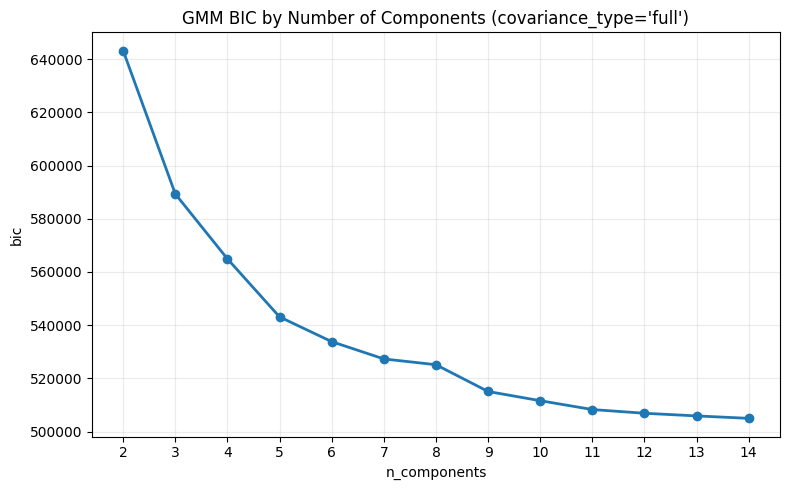

In [ ]:
full_cov_df = model_selection_df[model_selection_df["covariance_type"] == "full"].sort_values("n_clusters")

plt.figure(figsize=(8, 5))
plt.plot(full_cov_df["n_clusters"], full_cov_df["bic"], marker="o", linewidth=2)
plt.title("GMM BIC by Number of Clusters")
plt.xlabel("n_clusters")
plt.ylabel("bic")
plt.xticks(full_cov_df["n_clusters"])
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

#### Assign labels to our player data.

In [14]:
# Fit best model and assign cluster labels
best_row = model_selection_df.iloc[7]

best_gmm = GaussianMixture(
    n_components=int(best_row["n_clusters"]),
    covariance_type=best_row["covariance_type"],
    random_state=42,
    n_init=10,
)

clusters = best_gmm.fit_predict(X_pca)

player_clusters_df = player_df_10plus.copy()
player_clusters_df["cluster"] = clusters

print("Best model:")
print(best_row)
print("\nCluster sizes:")
print(player_clusters_df["cluster"].value_counts().sort_index())

player_clusters_df.head()

Best model:
covariance_type             full
n_components                   7
bic                 527305.98245
aic                525150.312798
Name: 7, dtype: object

Cluster sizes:
cluster
0    9919
1    5640
2    5468
3    6003
4     196
5    8019
6    4424
Name: count, dtype: int64


,uuid,nickname,games_played,latest_rank,avg_win_rate,avg_forfeit_rate,avg_time_win_ms,fastest_win_ms,avg_time_loss_ms,avg_time_forfeit_ms,avg_story_enter_the_nether_ms,avg_story_enter_the_end_ms,avg_time_win_sec,avg_time_loss_sec,avg_time_forfeit_sec,avg_story_enter_the_nether_sec,avg_story_enter_the_end_sec,cluster
5,00027c97590448f394c3678e14e461ae,MrKingsbury,15,33137.0,0.333333,0.600000,1.435601e+06,782471,2.538244e+06,1.492529e+06,365194.153846,2.106589e+06,1435.601000,2538.244000,1492.528778,365.194154,2106.589000,5
8,000332572f78457eafa71e5fbaf22db2,Kubson21_,78,8386.0,0.423077,0.423077,8.811283e+05,210209,1.042792e+06,5.830184e+05,175640.844156,9.792673e+05,881.128303,1042.791667,583.018424,175.640844,979.267273,1
10,00048da903b544729771ead2f0a2cffb,clickrtraineddog,136,40121.0,0.367647,0.595588,7.997705e+05,294323,1.793402e+06,9.177778e+05,323644.715447,1.696709e+06,799.770460,1793.402000,917.777802,323.644715,1696.709333,3
14,000738097742436d8c4d1ffbb2800548,KAITOKID6,397,6966.0,0.501259,0.110831,1.303258e+06,254334,1.330849e+06,1.156501e+06,215720.015190,1.249773e+06,1303.258050,1330.849039,1156.500705,215.720015,1249.773069,6
18,0008a4b72b874ccb9a363ba086b932a6,DOOMOFDEPLUSHIE,126,39277.0,0.428571,0.539683,8.994731e+05,291965,1.532241e+06,8.688375e+05,296972.558333,1.760561e+06,899.473074,1532.241000,868.837529,296.972558,1760.560667,3


In [15]:
# Quick cluster profile on the original (non-log) feature scales
cluster_profile = (
    player_clusters_df
    .groupby("cluster")[feature_cols]
    .mean()
    .round(3)
)

cluster_profile

,games_played,latest_rank,avg_win_rate,avg_forfeit_rate,avg_time_win_ms,fastest_win_ms,avg_time_loss_ms,avg_time_forfeit_ms,avg_story_enter_the_nether_ms,avg_story_enter_the_end_ms
cluster,,,,,,,,,,
0,47.376,26901.780,0.446,0.423,1191895.039,325843.498,1899874.834,1159851.901,319011.031,1848195.461
1,82.080,8573.433,0.478,0.258,1058975.562,297232.167,1277935.727,902207.725,212263.664,1162018.877
2,363.267,13900.440,0.460,0.336,943840.294,210448.334,1284528.422,827670.835,215234.657,1178789.611
3,146.239,29312.103,0.428,0.457,1078106.094,267442.094,1734696.508,1012788.061,293507.705,1662838.337
4,753.628,15668.010,0.465,0.328,959610.628,112707.158,1322543.735,822237.433,223958.161,1221364.706
5,19.545,20104.620,0.410,0.422,1191644.586,487438.551,1833116.902,1101627.005,304464.658,1773675.245
6,298.751,10837.423,0.473,0.282,1089568.888,235761.571,1349838.988,925504.440,227627.132,1233287.532


## Feature Plots by Cluster


C:\Users\Brandon\AppData\Local\Temp\ipykernel_4636\34475072.py:2: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab10", len(clusters_sorted))


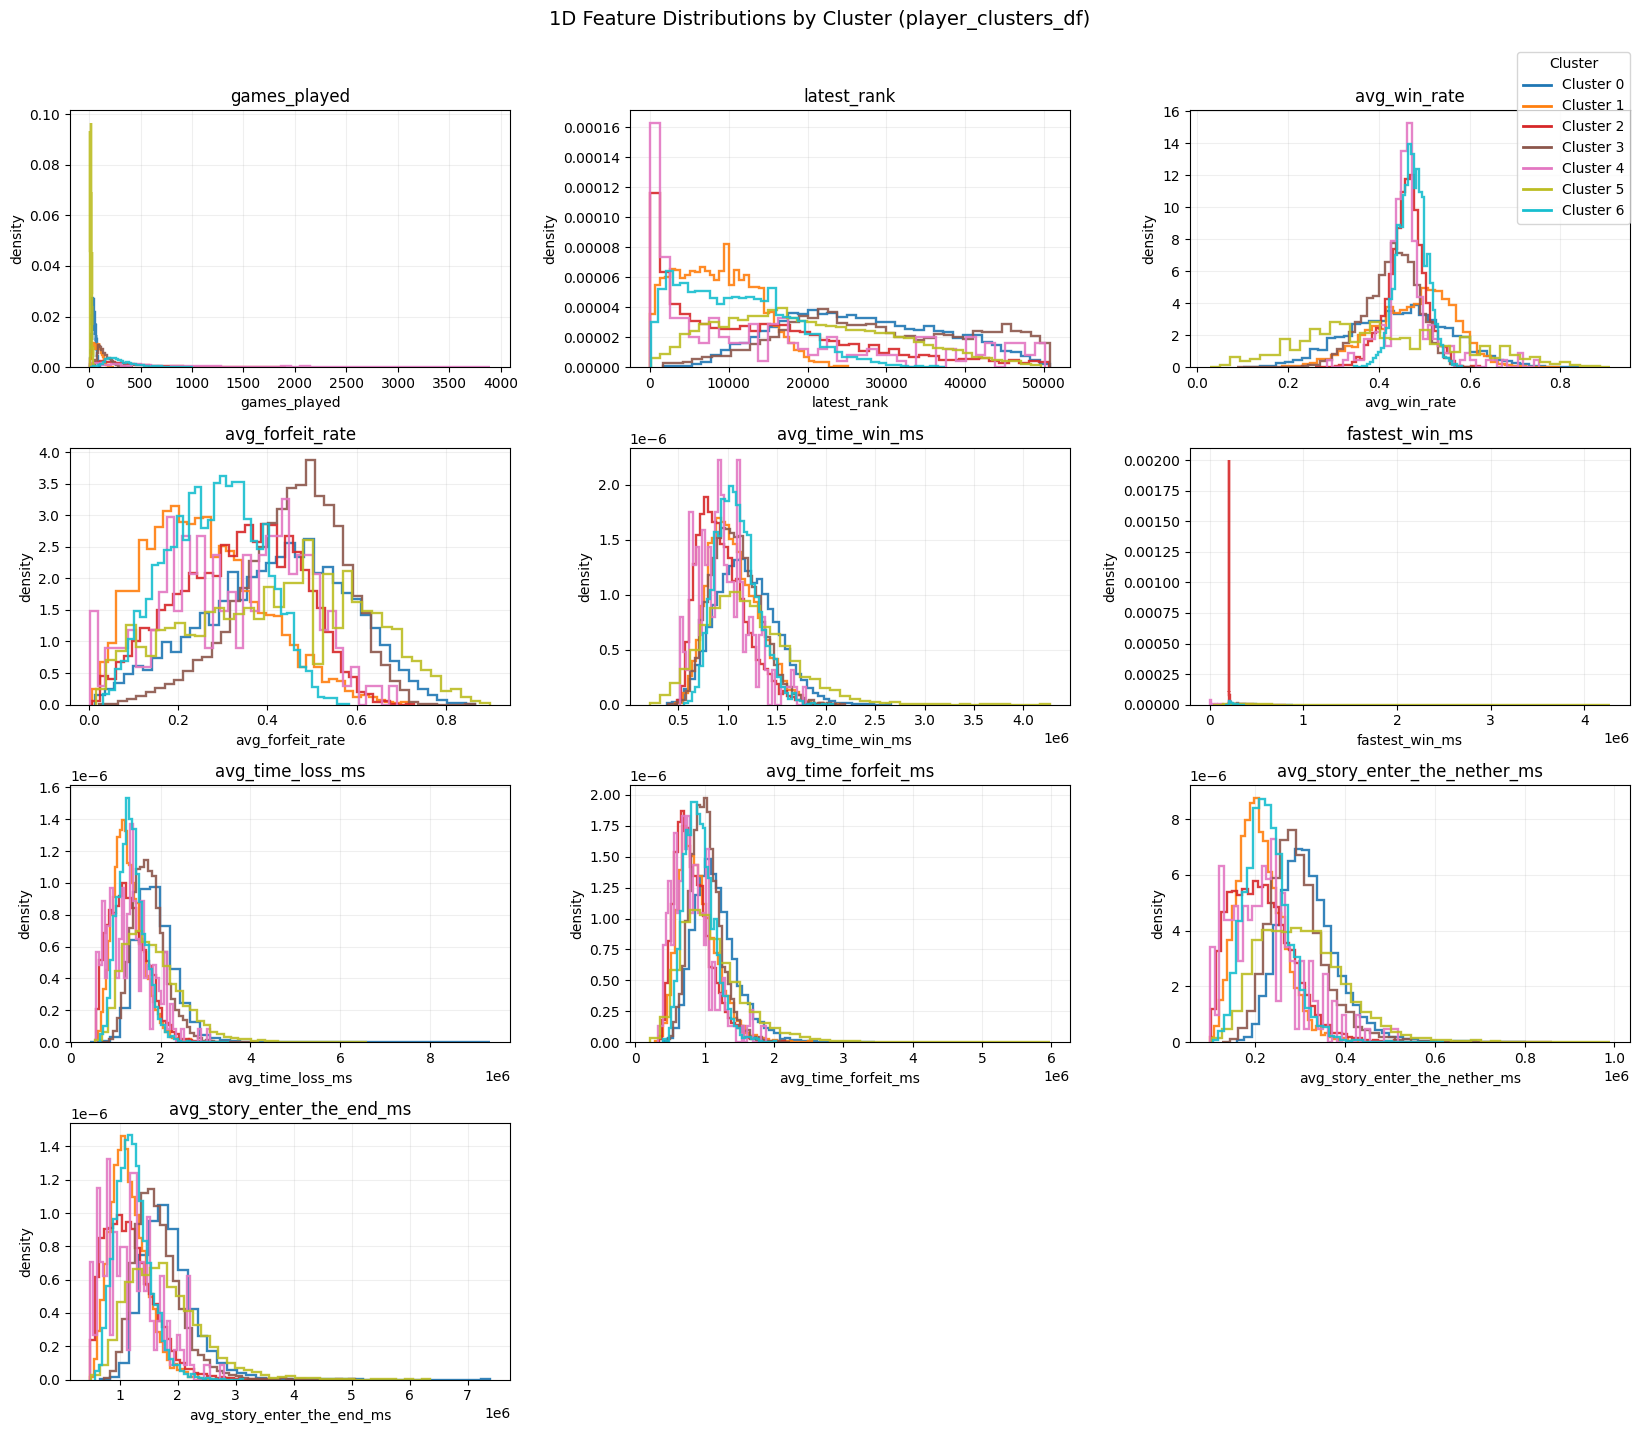

In [ ]:
clusters_sorted = sorted(player_clusters_df["cluster"].unique())
cmap = plt.cm.get_cmap("tab10", len(clusters_sorted))
cluster_colors = {cluster: cmap(i) for i, cluster in enumerate(clusters_sorted)}

n_features = len(feature_cols)
n_cols = 3
n_rows = math.ceil(n_features / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5.5 * n_cols, 3.5 * n_rows))
axes = axes.flatten()

for idx, feature in enumerate(feature_cols):
    ax = axes[idx]
    for cluster in clusters_sorted:
        values = player_clusters_df.loc[player_clusters_df["cluster"] == cluster, feature]
        ax.hist(
            values,
            bins=40,
            density=True,
            histtype="step",
            linewidth=1.7,
            color=cluster_colors[cluster],
            alpha=0.9,
        )

    ax.set_title(feature)
    ax.set_xlabel(feature)
    ax.set_ylabel("density")
    ax.grid(alpha=0.2)

for idx in range(n_features, len(axes)):
    axes[idx].axis("off")

legend_handles = [
    Line2D([0], [0], color=cluster_colors[c], lw=2, label=f"Cluster {c}") for c in clusters_sorted
]

fig.legend(handles=legend_handles, title="Cluster", loc="upper right", bbox_to_anchor=(0.995, 0.995))
fig.suptitle("Feature Distributions by Cluster", fontsize=14, y=1.02)
fig.tight_layout()
plt.show()

#### Excluding clusters with extreme density for better visualizations of some features

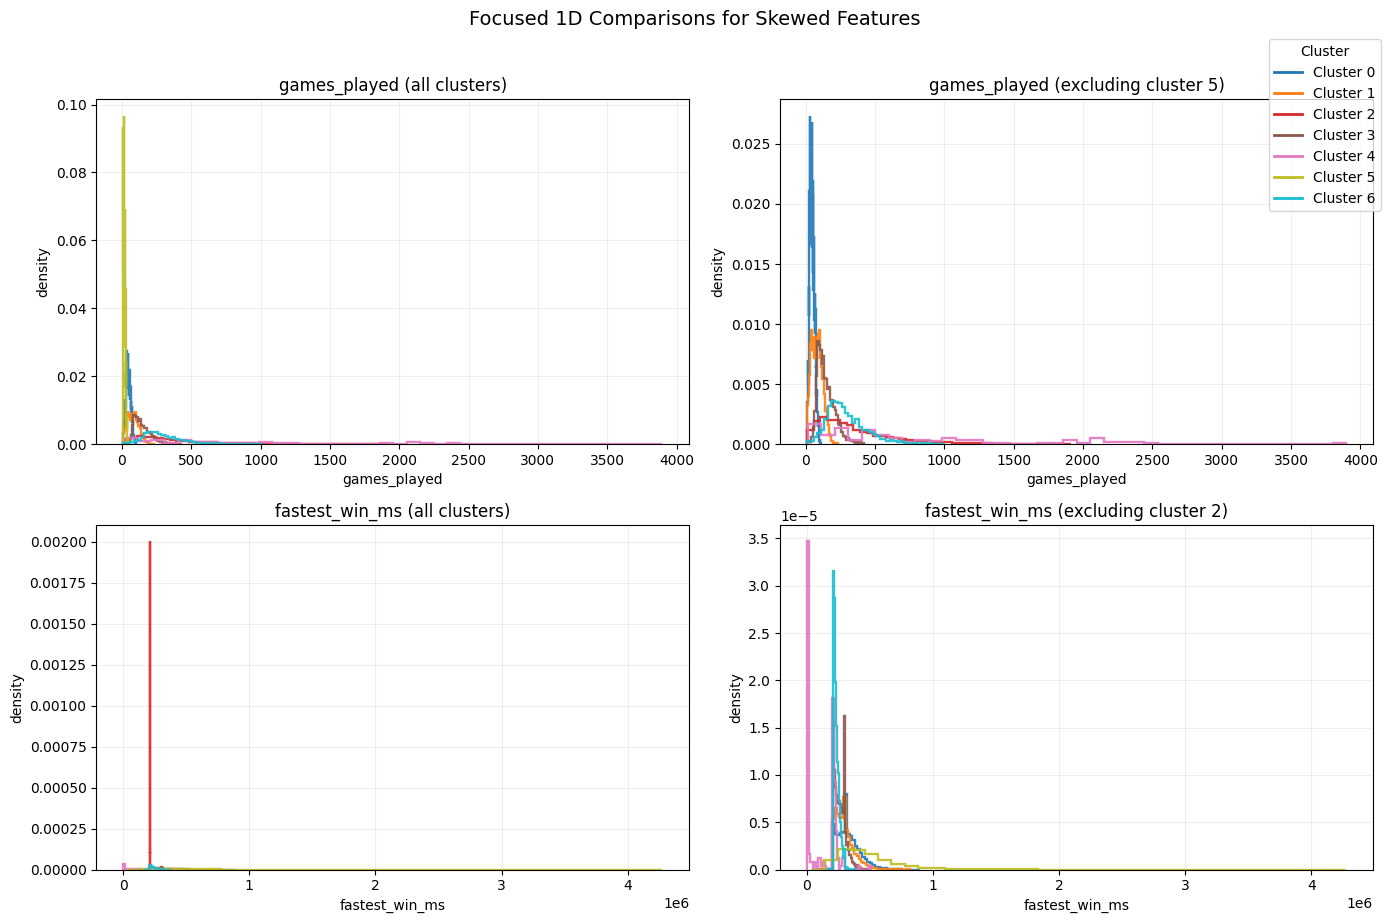

In [ ]:
# Focused comparison plots for skewed features
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

plot_specs = [
    ("games_played", None, "games_played (all clusters)"),
    ("games_played", {5}, "games_played (excluding cluster 5)"),
    ("fastest_win_ms", None, "fastest_win_ms (all clusters)"),
    ("fastest_win_ms", {2}, "fastest_win_ms (excluding cluster 2)"),
]

for ax, (feature, excluded_clusters, title) in zip(axes.flatten(), plot_specs):
    for cluster in clusters_sorted:
        if excluded_clusters and cluster in excluded_clusters:
            continue

        values = player_clusters_df.loc[player_clusters_df["cluster"] == cluster, feature]
        ax.hist(
            values,
            bins=40,
            density=True,
            histtype="step",
            linewidth=1.7,
            color=cluster_colors[cluster],
            alpha=0.9,
        )

    ax.set_title(title)
    ax.set_xlabel(feature)
    ax.set_ylabel("density")
    ax.grid(alpha=0.2)

legend_handles = [
    Line2D([0], [0], color=cluster_colors[c], lw=2, label=f"Cluster {c}") for c in clusters_sorted
]

fig.legend(handles=legend_handles, title="Cluster", loc="upper right", bbox_to_anchor=(0.995, 0.995))
fig.suptitle("Focused Comparisons for Skewed Features", fontsize=14, y=1.02)
fig.tight_layout()
plt.show()

#### 1D Feature visualizations using cluster means

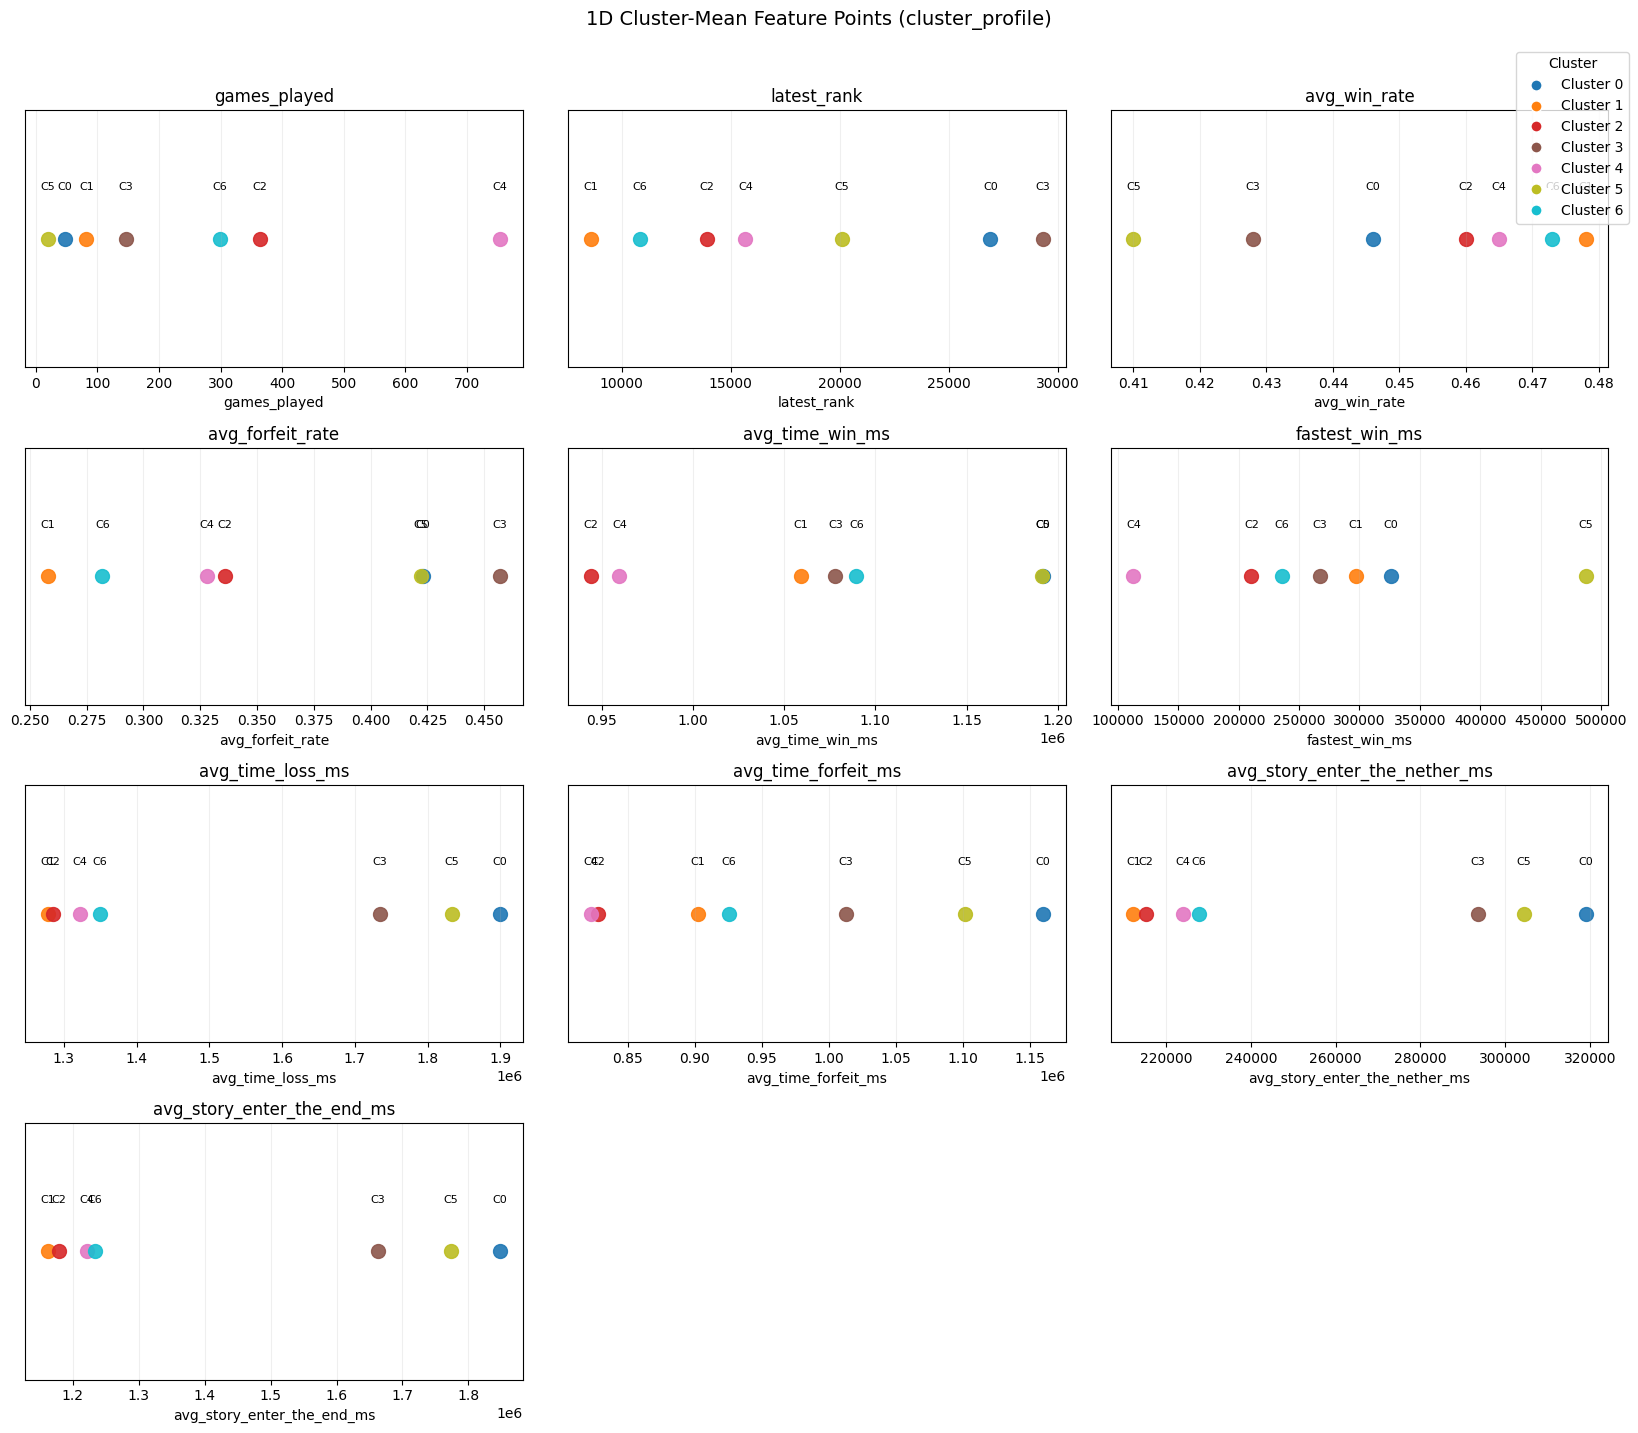

In [ ]:
cluster_profile_plot = cluster_profile.reset_index()
clusters_profile_sorted = sorted(cluster_profile_plot["cluster"].unique())

n_features = len(feature_cols)
n_cols = 3
n_rows = math.ceil(n_features / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5.5 * n_cols, 3.5 * n_rows))
axes = axes.flatten()

for idx, feature in enumerate(feature_cols):
    ax = axes[idx]

    for cluster in clusters_profile_sorted:
        x_val = cluster_profile_plot.loc[cluster_profile_plot["cluster"] == cluster, feature].iloc[0]
        ax.scatter(
            x_val,
            0,
            color=cluster_colors.get(cluster, "gray"),
            s=100,
            alpha=0.9,
        )
        ax.text(x_val, 0.02, f"C{cluster}", ha="center", va="bottom", fontsize=8)

    ax.set_title(feature)
    ax.set_xlabel(feature)
    ax.set_yticks([])
    ax.set_ylabel("")
    ax.grid(alpha=0.2, axis="x")

for idx in range(n_features, len(axes)):
    axes[idx].axis("off")

legend_handles = [
    Line2D([0], [0], marker="o", color="w", markerfacecolor=cluster_colors.get(c, "gray"), markersize=8, label=f"Cluster {c}")
    for c in clusters_profile_sorted
]

fig.legend(handles=legend_handles, title="Cluster", loc="upper right", bbox_to_anchor=(0.995, 0.995))
fig.suptitle("1D Cluster-Mean Feature Points", fontsize=14, y=1.02)
fig.tight_layout()
plt.show()